In [9]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tensorflow.keras.models import load_model
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    balanced_accuracy_score, precision_score, recall_score,
    cohen_kappa_score, confusion_matrix)

In [10]:
ROOT_DIR = Path.cwd().parents[1]
sys.path.append(str(ROOT_DIR / "src" / "data_preprocessing"))
from normalize_fn import load
labels_file  = ROOT_DIR / "datasets" / "labels.csv"
model_file   = ROOT_DIR / "src" / "model_training" / "checkpoints" / "final_model.h5"
results_dir  = ROOT_DIR / "src" / "model_training" / "results"
results_dir.mkdir(exist_ok=True)
label_threshold = 30
norm = 'norm'

In [11]:
model = load_model(str(model_file))
labels_df = pd.read_csv(labels_file)
train_features, val_features, all_train_features, test_features, train_targets, val_targets, all_train_targets, test_targets = load(norm=norm)

c:\Users\mayak\anaconda3\envs\deepsyn_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


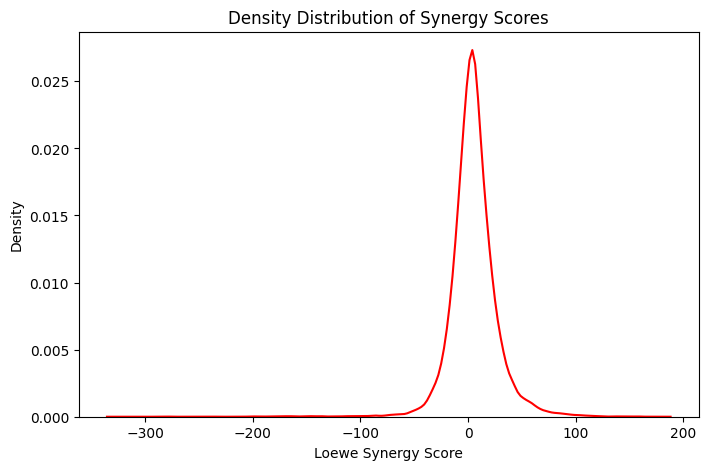

In [12]:
true_synergy = labels_df['synergy'].values
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(true_synergy, color='red', ax=ax)
ax.set_xlabel('Loewe Synergy Score')
ax.set_ylabel('Density')
ax.set_title('Density Distribution of Synergy Scores')
plt.savefig(results_dir / 'density_plot.png', dpi=150)
plt.show()

In [26]:
print(f"Statistics :")
print(f"  Min      : {true_synergy.min():.2f}")
print(f"  Max      : {true_synergy.max():.2f}")
print(f"  Median   : {np.median(true_synergy):.2f}")
print(f"  Std      : {true_synergy.std():.2f}")

Statistics :
  Min      : -326.46
  Max      : 179.12
  Median   : 4.38
  Std      : 22.89


In [19]:
all_features    = np.vstack([all_train_features, test_features])
all_predictions = model.predict(all_features).flatten()
labels_train   = labels_df[labels_df['fold'] != 0]
labels_test    = labels_df[labels_df['fold'] == 0]
labels_ordered = pd.concat([labels_train, labels_test], axis=0).reset_index(drop=True)
true_synergy_all = labels_ordered['synergy'].values
y_true_all = (true_synergy_all >= label_threshold).astype(int)

721/721 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step


In [20]:
roc_auc = roc_auc_score(y_true_all, all_predictions)
pr_auc  = average_precision_score(y_true_all, all_predictions)

In [21]:
val_predictions = model.predict(val_features).flatten()
val_labels_df   = labels_df[labels_df['fold'] == 1].reset_index(drop=True)
val_synergy     = val_labels_df['synergy'].values
y_val_true      = (val_synergy >= label_threshold).astype(int)
thresholds  = np.percentile(val_predictions, np.arange(1, 100, 1))
best_thresh = None
best_bacc   = 0
for t in thresholds:
    y_val_pred = (val_predictions >= t).astype(int)
    bacc = balanced_accuracy_score(y_val_true, y_val_pred)
    if bacc > best_bacc:
        best_bacc   = bacc
        best_thresh = t
print(f"\nOptimized prediction threshold : {best_thresh:.4f}")


145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

Optimized prediction threshold : 11.3244


In [22]:
y_pred_all = (all_predictions >= best_thresh).astype(int)
acc   = accuracy_score(y_true_all, y_pred_all)
bacc  = balanced_accuracy_score(y_true_all, y_pred_all)
prec  = precision_score(y_true_all, y_pred_all, zero_division=0)
tpr   = recall_score(y_true_all, y_pred_all, zero_division=0)
kappa = cohen_kappa_score(y_true_all, y_pred_all)
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()
tnr = tn / (tn + fp)

In [25]:
print(f"\nClassification Metrics :")
print(f"  ROC AUC : {roc_auc:.4f} ")
print(f"  PR  AUC : {pr_auc:.4f}  ")
print(f"  ACC     : {acc:.4f}  ")
print(f"  BACC    : {bacc:.4f}  ")
print(f"  PREC    : {prec:.4f}  ")
print(f"  TPR     : {tpr:.4f}  ")
print(f"  TNR     : {tnr:.4f} ")
print(f"  Kappa   : {kappa:.4f}  ")


Classification Metrics :
  ROC AUC : 0.9168 
  PR  AUC : 0.7178  
  ACC     : 0.7987  
  BACC    : 0.8292  
  PREC    : 0.2925  
  TPR     : 0.8664  
  TNR     : 0.7920 
  Kappa   : 0.3495  
